In [1]:
import sys
from pyprojroot import here

sys.path.insert(0, str(here()))

import pandas as pd
import numpy as np
import xarray as xr

import pymc as pm
import pytensor.tensor as pt
import matplotlib.pyplot as plt
import arviz as az
import pymc_extras as pmx

from scipy import sparse
from scipy.linalg import solve
from scipy.sparse.linalg import spsolve

from libpysal.weights import KNN, fuzzy_contiguity, w_union, W
import networkx as nx
import warnings

import os
from os.path import exists

import pathlib

import pytensor
from laos_gggi.model import add_data
from laos_gggi.plotting import configure_plot_style

from laos_gggi.data_functions import load_emdat_data, load_shapefile, load_rivers_data

config = {
    'figure.figsize':(14,4),
    'figure.constrained_layout.use':True,
    'figure.facecolor':'w',
    'axes.grid':False,
    'grid.linewidth':0.5,
    'grid.linestyle':'--',
    'axes.spines.top':False,
    'axes.spines.bottom':False,
    'axes.spines.left':False,
    'axes.spines.right':False
}

plt.rcParams.update(config)


SEED = sum(list(map(ord, 'climate_bayes')))
rng = np.random.default_rng(SEED)

In [2]:
from laos_gggi import load_shapefile
from laos_gggi.replication_data import create_replication_data
from laos_gggi.data_functions import load_emdat_data, load_all_data
from laos_gggi.sample import sample_or_load

# Event data

In [3]:
df = (create_replication_data()
        .rename(columns={'ISO':'iso'})
        .set_index(["iso", "year"]))

In [4]:
#Load shapefiles
world = (load_shapefile('world', repair_ISO_codes=True)
            .rename(columns={'ISO_A3':'iso'})
            .set_index('iso'))
laos = load_shapefile('laos')

# Helper functions

In [5]:
def damage_plot(iso, idata, df = None, cls='hydro', group='posterior_predictive', var_name = 'y_hat'):
    fig, ax = plt.subplots()
    data = idata[group][var_name].sel(obs_iso=iso, obs_disaster_class=cls).groupby('obs_year').mean()
    if df is not None:
        targets = df.query('iso == @iso & disaster_class == @cls').groupby('year')['Total_Damage_Adjusted'].mean().resample('YS').last()
        ax.scatter(targets.index, targets.values, color='tab:red', zorder=100)
    mu = data.quantile(0.5, dim=['chain', 'draw']).to_dataframe()[var_name].resample('YS').last()

    hdi_80 = az.hdi(data, hdi_prob=0.8)[var_name].to_dataframe()[var_name].unstack('hdi').resample('YS').last()
    hdi_94 = az.hdi(data)[var_name].to_dataframe()[var_name].unstack('hdi').resample('YS').last()

   
    ax.scatter(mu.index, mu.values, s=70)

    ax.vlines(mu.index, *hdi_80.values.T, lw=3)
    ax.vlines(mu.index, *hdi_94.values.T)
    ax.grid(ls='--', lw=0.5)
    ax.set(title = f'{iso} - {cls}')
    plt.show()

In [6]:
def plot_predictions(idata, 
                     iso: str,
                     group: str = 'posterior_predictive',
                     var_name: str = 'y_hat',
                     obs_name: str | None = None,
                     data: pd.DataFrame | None = None,
                     **kwargs):
    if group not in ['prior', 'posterior', 'prior_predictive', 'posterior_predictive']:
        raise ValueError(f'Invalid group {group}')
    
    if obs_name and data is None:
        obs_df = idata.observed_data.sel(obs_iso=iso)[obs_name].to_dataframe()[obs_name].drop_duplicates().unstack('disaster')
    elif data is not None:
        obs_df = data.xs(level=0, key=iso)
        
    iso_idata = idata[group][var_name].sel(obs_iso = iso)
    mu = iso_idata.mean(dim=['chain', 'draw'])
    
    index = mu['obs_year'].values
    disasters = mu['disaster'].values
    
    fig, ax = plt.subplots(1, 2, **kwargs)
    
    for disaster, axis in zip(disasters, fig.axes):
        axis.plot(index, mu.sel(disaster=disaster).values, color='tab:blue')

        if obs_name:
            axis.plot(index, obs_df[disaster].values, color='k', marker='o')
    
        for hdi_prob in np.linspace(0.05, 0.95, 25)[::-1]:
            hdi = az.hdi(iso_idata.sel(disaster=disaster), hdi_prob=hdi_prob)[var_name]
            axis.fill_between(index, *hdi.values.T, color='tab:blue', alpha=0.1)
        axis.set(xlabel="Year", ylabel = "Disaster Count", title=f"{iso} {disaster.title()}")

    plt.show();
    

In [7]:
def ppc_plot(iso, classes, 
             idata=None,
             predictions=None,
             group='posterior', 
             target='y_hat',
             hdi_lim=1.0):
    fig, ax = plt.subplots(1, 2, figsize=(14, 4))
    
    if idata is None and predictions is None:
        raise ValueError('Need at least one of idata or predictions')
    
    for cls, axis in zip(classes, fig.axes):
        sel = {'obs_iso': iso, 'obs_disaster_class':cls}

        if predictions is None:
            pp = idata[f'{group}_predictive'].sel(obs_iso = iso)
        else:
            pp = predictions['predictions'].sel(obs_iso = iso)
        
        if cls not in pp.coords['obs_disaster_class']:
            axis.set_title(cls)
            continue
        else:
            pp = pp.sel(obs_disaster_class = cls)
        
        if idata is not None:
            obs = idata.observed_data.sel(obs_iso = iso)
            observed = True
        if cls not in obs.coords['obs_disaster_class']:
            obs = pp.copy().mean(dim=['chain', 'draw']) # Dummy data, otherwise plot_ppc throws a fit
            observed=False
        else:
            obs = obs.sel(obs_disaster_class = cls)
        
        pp[target] = pp[target] + np.random.uniform(0, 1e-6, size=pp[target].values.shape)
        
        az.plot_ppc(az.InferenceData(posterior_predictive=pp,
                                     observed_data=obs),
                    ax=axis,
                    var_names=target,
                    observed=observed,
                    legend=False)
            
        axis.set_title(cls)
        
        if hdi_lim < 1.0:
            hdi = az.hdi(pp, hdi_prob=hdi_lim)[target]
            higher = hdi.sel(hdi = 'higher').max()
            axis.set_xlim(0, higher)


### Damage curves model

In [8]:
def curves_model( coords, df , 
                 codes_idx_joint, 
                 features_events,
                 damage_features_d_stand, 
                 class_idx_joint):
    
    with pm.Model(coords = coords) as model:
        ######################################## event model ########################################
        X_event = pm.Data('X', df[features_events])
        iso_idx_pt = pm.Data('iso_idx', codes_idx_joint, dims=['obs_idx'])
    
        latent_iso_events = pm.Flat('latent_iso_events', dims=['iso', 'features_events'])
        
        # Actual Model    
        country_loc = pm.Flat('country_loc', dims=['disaster'])
        country_scale = pm.Flat('country_scale',dims=['disaster'])
        country_offset = pm.Flat('country_offset', dims=['iso', 'disaster'])
    
        country_effect = pm.Deterministic('country_effect',
                                          country_loc[None] + country_scale[None] * country_offset, 
                                          dims=['iso', 'disaster'])
        
        
        # beta_sigma = 2.5 / df_joint[features_events].std().values[None] * df[disasters].std().values[:, None]
        beta = pm.Flat('beta', dims=['features_events', 'disaster'])
        beta_GY = pm.Flat('beta_GY', dims=['features_events', 'disaster'])    
        coef_effect = X_event @ beta + (latent_iso_events @ beta_GY)[iso_idx_pt]
        mixture = pm.Flat("mixture",
                                   dims = ["iso", 'disaster'])
    
        latent_rate = (country_effect + mixture)[iso_idx_pt] + coef_effect
        mu = pt.softplus(latent_rate)
        
        zero_prob = pm.Flat('zero_prob',dims=['disaster'])
        alpha = pm.Flat('alpha',dims=['disaster'])
        
        y_hat_n_events = pm.ZeroInflatedNegativeBinomial('y_hat_n_events',
                                                psi=zero_prob,
                                                mu=pt.clip(mu, 1e-6, 300),
                                                alpha=alpha,
                                                observed = np.zeros((df.shape[0],2)),
                                                dims= ['obs_idx', 'disaster'])
    
        ######################################## Damages model ########################################
        X_damage = pm.Data('X_damage',   df[damage_features_d_stand], 
                dims=['obs_idx', 'features_damages'])
    
        
        class_idx_pt = pm.Data('class_idx', class_idx_joint, dims=['obs_idx'])
        
        latent_iso_damage = pm.Flat('latent_iso_damage', dims=['iso', 'features_damages'])
        
        country_loc_damage = pm.Flat('country_loc_damage',  dims=['disaster'])
        country_scale_damage = pm.Flat('country_scale_damage', dims=['disaster'])
        country_offset_damage = pm.Flat('country_offset_damage', dims=['iso', 'disaster'])
        country_effect_damage = pm.Deterministic('country_effect_damage', 
                                                 country_loc_damage + country_scale_damage * country_offset_damage,
                                          dims=['iso', 'disaster'])
    
        
        
        beta_damage = pm.Flat('beta_damage', dims=['features_damages', 'disaster'])
        beta_GY_damage = pm.Flat('beta_GY_damage', dims=['features_damages', 'disaster'])    
        coef_effect_damage = X_damage @ beta_damage + (latent_iso_damage @ beta_GY_damage)[iso_idx_pt]
    
        mixture_damage = pm.Flat("mixture_damage",
                                   dims = ["iso", 'disaster'])
    
        mu = (country_effect_damage + mixture_damage)[iso_idx_pt] + coef_effect_damage
        
    
        sigma = pm.Flat('sigma', dims=['disaster'])
        
        mus = [mu[pt.eq(class_idx_pt, i), i] for i in range(len(classes))]
        mu_damage = pm.Deterministic('mu_damage', pt.concatenate(mus, axis=0), dims=['obs_idx'])
        
        p_zero_damage = pm.Flat('p_zero_damage',dims=['disaster'])
        y_hat_damages = pm.HurdleLogNormal('y_hat_damages',
                       mu=mu_damage,
                       sigma= sigma[class_idx_pt],
                       psi=(1 - p_zero_damage)[class_idx_pt],
                       observed = np.zeros((df.shape[0],)) ,
                       dims=['obs_idx'])
    
        #################################### Damage curves ####################################
        damages_curves = pm.Deterministic("damages_curves", y_hat_damages * y_hat_n_events[: ,1], dims=['obs_idx'])

    return model

### Points model

In [9]:
# Points model
from copy import deepcopy
from pymc.model.transform.optimization import freeze_dims_and_data

floatX = pytensor.config.floatX


def points_model(coords , beta_point_features, df , gp_data, ):
    with pm.Model(coords = coords) as model:
        #################################### Points model####################################
        # Set data
        event_features_data = add_data(features= beta_point_features ,  target = None, df = df,
                                   dims=['obs_idx', 'features'])
        X_gp = pm.Data("X_gp", gp_data.astype(floatX), dims=['obs_idx', 'gp_feature'])
    
        #Flat variables
        country_effect_points = pm.Flat("country_effect_points", dims = ["iso_points"])    
        beta_points = pm.Flat("beta_points", dims = ["beta_point_features"])
        
        # HSGP component
        eta = pm.Flat("eta")
        ell = pm.Flat("ell", dims=["gp_feature"])
        cov_func = eta**2 * pm.gp.cov.Matern52(input_dim=2, ls=ell)
    
        m0, m1, c = 35, 35, 1.5
        gp = pm.gp.HSGP(m=[m0, m1], c=c, cov_func=cov_func)
        gp._X_center = compute_center( pred_df_stand_dict[year][["lat_centered", "long_centered"]].values.astype(floatX))
    
        phi, sqrt_psd = gp.prior_linearized(X=X_gp)
    
        basis_coeffs = pm.Flat("basis_coeffs", size=gp.n_basis_vectors)
    
        HSGP_component = pm.Deterministic('HSGP_component', phi @ (basis_coeffs * sqrt_psd), dims=['obs_idx'])
    
        # Point model components
        event_features_component = pm.Deterministic('event_features_component', 
                                                    event_features_data @ beta_points, dims=['obs_idx'])

        event_features_component_inv_logit = pm.Deterministic('event_features_component_inv_logit', 
                                           pm.math.invlogit(event_features_component))

        HSGP_component_inv_logit = pm.Deterministic('HSGP_component_inv_logit', 
                                                   pm.math.invlogit(HSGP_component))
        
        logit_p = pm.Deterministic('logit_p', country_effect_points[ISO_idx_laos] + event_features_component 
                                   + HSGP_component, dims=['obs_idx'])
        event_prob_y_hat = pm.Deterministic('event_prob_y_hat', pm.math.invlogit(logit_p), dims=['obs_idx'])

    return model

In [158]:
from scipy import interpolate


def obtain_base_table(idata, posterior_predictive_input = False):
    computed_ry_damage = {}
    curves_df = pd.DataFrame( )
    
    for year in curve_years:

        if posterior_predictive_input:
            damages = idata.damages_curves.sel(obs_iso='LAO',obs_year = year).values.ravel()
        else:
            damages = idata.posterior_predictive.damages_curves.sel(obs_iso='LAO',obs_year = year).values.ravel()
        data = np.sort(damages)
        n = len(data)
        cdf_vals = np.linspace(1/n, 1, n)
        
        # Interpolate inverse CDF (PPF)
        ppf_func = interpolate.interp1d(cdf_vals, data, bounds_error=False, fill_value=(data[0], data[-1]))
        
        def compute_ry_damage(ry):
            return ppf_func(1 - 1/ry)
        
        rys = np.linspace(1, 100, num=10000)
        rys = np.append(rys, np.repeat(100, 10)/ np.array([0.01, 0.1, 0.2, 0.5, 1, 2, 10, 25, 50, 75]) )
        percentile = np.repeat(100, 10010) / rys
        year_ = year.year
        computed_ry_damage[year_] = pd.DataFrame({'percentile_inv': percentile, f'{year_}': compute_ry_damage(rys)},
                                                     ).set_index('percentile_inv').T
    
        #concat
        curves_df = pd.concat([curves_df,computed_ry_damage[year_].T], axis=1)
        
    curves_df= curves_df.reset_index()
    curves_df = curves_df.assign( percentile = lambda x:  100 -x["percentile_inv"] ).set_index('percentile')
    curves_df = curves_df.sort_index(ascending= True)

    return curves_df


    # Build the return years table
def build_return_years_curve(curves_df ):
    return_years_table = curves_df.loc[np.repeat(100,10)- percentile[-10:]].drop_duplicates()
    
    return_years_table = return_years_table.assign( value = lambda x: (100 / x['percentile_inv']).round(decimals = 1) ) 
    return_years_table = (return_years_table.assign(
        return_years = lambda x: '1-in-' + x['value'].astype(str)  + ' year flood ' )
                          .drop(columns = ['value', 'percentile_inv']).set_index('return_years',  ))
    return return_years_table

## Dropping row missing covariates

There are years for which we don't have covariate data; these have to be dropped. We can keep missing damage and event data. These are probably zero, but maybe not. The pattern of missingness isn't random.

In [10]:
disasters = ["climatological_disasters", "hydrological_disasters"]
effects = ['Total_Damage_Adjusted_hydro', 'Total_Damage_Adjusted_clim']
features = ["ln_population_density", 
            "ln_gdp_pc", 
            "square_ln_gdp_p", 
            "precip_deviation", 
            "co2", 
            "population"]

In [11]:
df.dropna(subset=features, inplace=True)

In [12]:
events_idx = xr.Coordinates.from_pandas_multiindex(df.index.rename({'year': 'obs_year', 'iso': 'obs_iso'} ), dim= "obs_idx" )

## Reconcile EMDAT and shapefile ISO codes

In [13]:
df_iso = df.index.get_level_values('iso').unique()
world_iso = world.index.unique()

In [14]:
# Codes in EMDAT but not in world
", ".join(list(set(df_iso) - set(world_iso)))

''

In [15]:
# Codes in shapefile but not in EMDAT
", ".join(list(set(world_iso) - set(df_iso)))

'KNA, COK, IOT, KIR, ABW, HMD, MLT, VIR, VEN, CPV, ATF, JAM, SLB, GRL, TON, COM, NIU, AIA, SHN, NRU, GGY, DMA, STP, LIE, PCN, MDV, SMR, SGS, PSE, PRK, WLF, TCA, VAT, SXM, PLW, FRO, HKG, SYC, CUW, GRD, VCT, PRI, BRB, TTO, ASM, GIB, CYM, UNK, BLM, JEY, MCO, MAC, AND, TUV, ATG, NFK, MSR, MNP, IMN, SGP, MHL, BHS, MAF, ISR, LUX, CYP, BHR, BMU, LCA, SPM, FLK, GUM, VGB, QAT, FSM'

In [16]:
# Drop codes not in both
common_codes = set(world_iso).intersection(set(df_iso))

df = df.query('iso in @common_codes').copy()
world = world.query('iso in @common_codes').copy()

In [17]:
# Get unique iso codes and years
code_idx, codes = pd.factorize(df.index.get_level_values("iso"), sort=True)
year_idx, years = pd.factorize(df.index.get_level_values("year"), sort=True)

In [18]:
y = df[disasters].copy().astype(float)

# Assume years without observed disasters had no disasters.
# **THIS IS A TERRIBLE ASSUMPTION **
# but sampling is too onerous without it.
y_filled = y.fillna(0)

# Damage data

In [19]:
emdat = load_emdat_data()

In [90]:
damage_events = (emdat['df_raw_filtered_adj']
           .loc[:, ['Start_Year', 'ISO', 'disaster_class', 'Total_Damage_Adjusted']]
           .dropna()
           .reset_index(drop=True)
           .rename(columns={'Start_Year':'year', 'ISO':'iso'}))

In [91]:
damage_events_full = (damage_events
     .groupby(['iso', 'year', 'disaster_class'])
     .apply(lambda x: x.assign(idx = np.arange(x.shape[0])), 
            include_groups=False)
     .reset_index()
     .set_index(['iso', 'year', 'disaster_class', 'idx']))

# Get unique iso codes and years
_, codes = pd.factorize(damage_events_full.index.get_level_values(0), sort=True)
_, years = pd.factorize(damage_events_full.index.get_level_values(1), sort=True)
_, classes = pd.factorize(damage_events_full.index.get_level_values(2))

power_set = pd.MultiIndex.from_product([codes, years, classes, [0]], names=['iso', 'year', 'disaster_class', 'idx'])
total = pd.MultiIndex.from_tuples(set(power_set.values).union(set(damage_events_full.index)), names=['iso', 'year', 'disaster_class', 'idx'])

damage_events_full = damage_events_full.reindex(total).sort_index().drop(columns=['level_3'])
df_damage_full = (pd.merge(damage_events_full.reset_index(),
                     df[features].reset_index(),
                     left_on=['iso', 'year'],
                     right_on=['iso', 'year'])
             
             # This sorting is super important; it ensures we blindly concat the predicted mean
             # by disaster class and everything will end up correct (because they're stacked in the data)
             .sort_values(by=['disaster_class', 'iso', 'year',])
             .reset_index(drop=True))
df_damage_full['Total_Damage_Adjusted'] = df_damage_full['Total_Damage_Adjusted'] / 1e6

In [92]:
df_damage = (pd.merge(damage_events.reset_index(),
                     df[features].reset_index(),
                     left_on=['iso', 'year'],
                     right_on=['iso', 'year'])
             
             # This sorting is super important; it ensures we blindly concat the predicted mean
             # by disaster class and everything will end up correct (because they're stacked in the data)
             .sort_values(by=['disaster_class', 'iso', 'year',])
             .reset_index(drop=True))
df_damage['Total_Damage_Adjusted'] = df_damage['Total_Damage_Adjusted'] / 1e6

In [93]:
df_damage_full = df_damage_full.query('iso in @df_damage.iso').copy()

In [94]:
# Get unique iso codes and years
iso_idx, codes = pd.factorize(df_damage['iso'], sort=True)
year_idx, years = pd.factorize(df_damage['year'], sort=True)
class_idx, classes = pd.factorize(df_damage['disaster_class'])

iso_to_idx = {code: idx for idx, code in enumerate(codes)}
year_to_idx = {year: idx for idx, year in enumerate(years)}
class_to_idx = {cls: idx for idx, cls in enumerate(classes)}

iso_idx_oos = np.array(list(map(iso_to_idx.get, df_damage_full.iso)))
year_idx_oos = np.array(list(map(year_to_idx.get, df_damage_full.year)))
class_idx_oos = np.array(list(map(class_to_idx.get, df_damage_full.disaster_class)))
                  
idx_cols = ["iso", "year", "disaster_class"]
rename_dict = {col: f'obs_{col}' for col in idx_cols}

idx_damages = (xr.Coordinates
           .from_pandas_multiindex(df_damage.set_index(idx_cols).index.rename(rename_dict) , 
                                   dim = "obs_idx"))
idx_oos =(xr.Coordinates
           .from_pandas_multiindex(df_damage_full.set_index(idx_cols).index.rename(rename_dict) , 
                                   dim = "obs_idx"))

### Load predictions


In [95]:
# Add prediction data

# Load predictions
predictions = pd.read_csv(here("data/climate_forecast.csv")).rename(columns = {"time": "Start_Year"})
predictions['iso'] = 'LAO'
# Load IPCC data
ipcc_preds = pd.read_csv(here("data/ippc_projections.csv"), index_col=  "Year").head(14)

# Create population density
predictions["population_density"] = predictions["Population"] / 236800 # Laos area in squared km hardcoded
predictions = predictions.rename(columns = {'Start_Year': 'year', 
                                            'Population': 'population',
                                              'dev_ocean_temp':'dev_from_trend_ocean_temp'})
predictions['year'] = pd.to_datetime(predictions['year'])

predictions['population'] = predictions['population'] / 1e6
predictions["real_gdp"] = predictions["real_gdp"] /  1e6


# Calculate logs
predictions["ln_population_density"] = np.log(predictions["population_density"])
predictions["ln_gdp_pc"] = np.log(predictions["real_gdp"])
predictions['square_ln_gdp_p'] = predictions["ln_gdp_pc"] **2

prediction_dates = [
                    pd.to_datetime('2024-01-01 00:00:00'),
                    pd.to_datetime('2025-01-01 00:00:00'), 
                    pd.to_datetime('2026-01-01 00:00:00'),
                    pd.to_datetime('2027-01-01 00:00:00'),
                    pd.to_datetime('2028-01-01 00:00:00'),
                    pd.to_datetime('2029-01-01 00:00:00'),
                    pd.to_datetime('2030-01-01 00:00:00'), 
                    pd.to_datetime('2031-01-01 00:00:00'),
                    pd.to_datetime('2032-01-01 00:00:00'),
                    pd.to_datetime('2033-01-01 00:00:00'),
                    pd.to_datetime('2034-01-01 00:00:00'),
                    pd.to_datetime('2035-01-01 00:00:00'),
                    pd.to_datetime('2036-01-01 00:00:00'),
                    pd.to_datetime('2037-01-01 00:00:00'),
                    pd.to_datetime('2040-01-01 00:00:00'),
                    pd.to_datetime('2045-01-01 00:00:00'),
                    pd.to_datetime('2050-01-01 00:00:00'),
                    pd.to_datetime('2055-01-01 00:00:00')]

shorter_pred = predictions.query('year in @prediction_dates').set_index(['iso', 'year' ] )

In [96]:
# Concat both dfs
df = pd.concat( [df, shorter_pred])

### Standardize data

In [97]:
# Damage features
damage_features_base = ['ln_population_density', 'ln_gdp_pc',
       'precip_deviation', 'co2', 'population']

damage_features_base_d = ['d_' + x for x in damage_features_base]
damage_features_base_d_stand = [x +"__standardized" for x in damage_features_base_d]

for x, d_x in zip(damage_features_base , damage_features_base_d):
    df_damage[d_x] = df_damage[x]

damage_features_d_stand = ['ln_population_density__standardized',
 'ln_gdp_pc__standardized',
 'ln_gdp_pc__standardized_squared',
 'precip_deviation__standardized',
 'co2__standardized',
 'population__standardized',
 ]

# event features
features_events = ["ln_population_density", "ln_gdp_pc", 'square_ln_gdp_p', "precip_deviation", "co2", "population" ]


all_features = features_events + damage_features_d_stand + ['d_ln_gdp_pc__standardized_squared' ]

In [98]:
#Standardize dfs
from laos_gggi.statistics import standardize

transformer_events, df_stand = standardize(df = df, columns = features_events)
transformer_damages, df_damage_stand = standardize(df = df_damage, columns = features_events)


df_joint_stand = pd.DataFrame(transformer_damages.transform(df[features_events]),columns = damage_features_d_stand, index = df.index)

df_joint_stand =  df_joint_stand.join(df )

# Obtain ln_gdp_squared
df_joint_stand['ln_gdp_pc__standardized_squared'] = df_joint_stand['ln_gdp_pc__standardized'] **2



In [99]:
# Drop duplicates
df_joint_stand = df_joint_stand.drop_duplicates()

# Combine models

In [100]:
#Load idatas
damages_idata  = az.from_netcdf('idata/dmg_model_5.nc')
events_idata  = az.from_netcdf('idata/events_model_4_v2.nc')

damage_idata_2 = damages_idata.copy()


#Rename to avoid conflicts merging
events_idata = events_idata.rename({'latent_iso': 'latent_iso_events',
                                    })


damages_idata = damages_idata.rename({"country_loc": "country_loc_damage",
                                     'country_scale': 'country_scale_damage',
                                     'country_offset': 'country_offset_damage',
                                     'country_effect':'country_effect_damage',
                                      'beta': 'beta_damage',
                                      'beta_GY': 'beta_GY_damage',
                                      'mixture': 'mixture_damage',
                                      'alpha_X': 'alpha_X_damage',
                                      'latent_iso': 'latent_iso_damage',
                                      'phi': 'phi_damage',
                                      'phi_climatological_disasters': 'phi_climatological_disasters_damage',
                                      'phi_hydrological_disasters': 'phi_hydrological_disasters_damage',
                                      'rho': 'rho_damage',
                                      'sigma_X': 'sigma_X_damage',
                                      'theta': 'theta_Damage',
                                      'p_zero': 'p_zero_damage',
                                      'mu': 'mu_damage',
                                    })

#Merge posteriors
merged_posteriors_0 = xr.merge([damages_idata.posterior.drop_vars(['mu_damage'] ).drop_dims('obs_idx'),
                              events_idata.posterior])

In [101]:
iso_idx, codes = pd.factorize(df_damage['iso'], sort=True)
year_idx, years = pd.factorize(df_damage['year'], sort=True)
class_idx, classes = pd.factorize(df_damage['disaster_class'])

iso_to_idx = {code: idx for idx, code in enumerate(codes)}
year_to_idx = {year: idx for idx, year in enumerate(years)}
class_to_idx = {cls: idx for idx, cls in enumerate(classes)}

iso_idx_oos = np.array(list(map(iso_to_idx.get, df_damage_full.iso)))
year_idx_oos = np.array(list(map(year_to_idx.get, df_damage_full.year)))
class_idx_oos = np.array(list(map(class_to_idx.get, df_damage_full.disaster_class)))
                  
idx_cols = ["iso", "year", "disaster_class"]

In [103]:
# iso codes
code_idx, codes = pd.factorize(df.reset_index()['iso'], sort=True)
codes_to_idx = {name: idx for idx, name in enumerate(codes)}
codes_idx_joint=  df_joint_stand.reset_index()['iso'].map(codes_to_idx.get)

# class codes
class_idx, classes = pd.factorize( df_damage['disaster_class'].replace({'Hydrometereological': 'hydro', 
                                                                      'Climatological': 'climate'} ))
class_to_idx = {name: idx for idx, name in enumerate(classes)}

df_joint_stand['disaster_class'] = 'hydro'
class_idx_joint =  df_joint_stand['disaster_class'].map(class_to_idx.get)

# years
year_idx, years = pd.factorize(df.index.get_level_values("year"), sort=True)
year_to_idx = {name: idx for idx, name in enumerate(years)}
year_idx_joint =  df_joint_stand.index.get_level_values("year").map(year_to_idx.get)

national_features = list(filter(lambda x: x != 'co2__standardized', damage_features_d_stand))
world_features = ['co2__standardized']

training_years = [dt.year for dt in years]

coords_combined = {
    'iso':codes,
    'year': [dt.year for dt in years],
    'disaster': ['climate', 'hydro'],
    'obs_idx': np.arange(df_joint_stand.shape[0]),
    'features_events':features_events,
    'features_damages': damage_features_d_stand,
    'world_feature': world_features,
    'national_feature': national_features,
    'fixed_effect': ['iso', 'year'],
    'latent': ['iso', 'year'],
    'year_os' :  [ dt.year for dt in list(years) + prediction_dates]
}


# Combine coords
combined_xr_idx =( xr.Coordinates.from_pandas_multiindex(df_joint_stand.reset_index().set_index(['iso', 'year', 'disaster_class'])
                                                         .index.rename({'iso':'obs_iso', 
                                                                        'year':'obs_year',
                                                                        'disaster_class': 'obs_disaster_class'}), 'obs_idx'))

base_df_joint_stand = df_joint_stand.copy()

In [33]:
#Combined

combined_model = curves_model(coords = coords_combined , df = df_joint_stand ,
                                codes_idx_joint = codes_idx_joint,
                                features_events = features_events,
                                damage_features_d_stand= damage_features_d_stand,
                                class_idx_joint = class_idx_joint )


In [35]:
from pymc.model.transform.optimization import freeze_dims_and_data
with freeze_dims_and_data(combined_model ) :
    idata_post_combined = pm.sample_posterior_predictive(merged_posteriors_0 , extend_inferencedata=False, 
                                                      compile_kwargs={'mode':'JAX'},
                                                var_names=[ 
                                                    'damages_curves', 
                                                           'y_hat_damages',
                                                    'y_hat_n_events']
                                                       )

    idata_post_combined = idata_post_combined.assign_coords(combined_xr_idx)

C:\Users\camil\miniforge3\envs\laos-climate-change\Lib\site-packages\pytensor\link\jax\linker.py:27: UserWarning: The RandomType SharedVariables [RNG(<Generator(PCG64) at 0x203A0610120>), RNG(<Generator(PCG64) at 0x203B5139B60>), RNG(<Generator(PCG64) at 0x203A0A55D20>), RNG(<Generator(PCG64) at 0x203A0610E40>)] will not be used in the compiled JAX graph. Instead a copy will be used.
  warnings.warn(
C:\Users\camil\miniforge3\envs\laos-climate-change\Lib\functools.py:912: UserWarning: Skipping `CheckAndRaise` Op (assertion: sigma > 0) as JAX tracing would remove it.
  return dispatch(args[0].__class__)(*args, **kw)
Sampling: [y_hat_damages, y_hat_n_events]


Output()

In [36]:
curve_years = prediction_dates = [pd.to_datetime('2000-01-01 00:00:00'),
                    pd.to_datetime('2010-01-01 00:00:00'),
                    pd.to_datetime('2018-01-01 00:00:00'), 
                    pd.to_datetime('2030-01-01 00:00:00'),
                    pd.to_datetime('2045-01-01 00:00:00'),
                    pd.to_datetime('2055-01-01 00:00:00'),]

In [139]:
# Compute base table
curves_df = obtain_base_table(idata_post_combined)

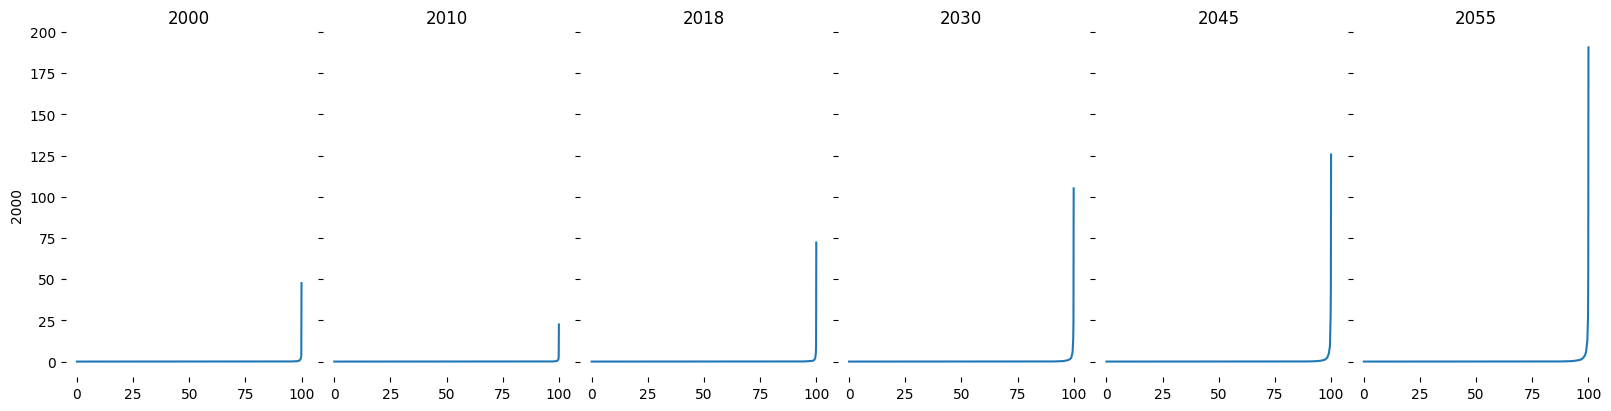

In [140]:
import seaborn as sns
fig, axes = plt.subplots(1, 6, figsize = (16, 4), sharey= True)
axes = axes.flatten()

for year, n in zip(curve_years, range(0,8)):
    sns.lineplot( data = curves_df , x = list(curves_df.index), y = f'{year.year}', ax= axes[n])
    # axes[n].invert_xaxis()
    axes[n].set_title(f'{year.year}')
    

In [39]:
# Build the return years table
return_years_table =  build_return_years_curve( curves_df=  curves_df)

return_years_table.to_csv(here('data/return_years_table.csv'))

In [143]:
return_years_table

,2000,2010,2018,2030,2045,2055
return_years,,,,,,
1-in-10000.0 year flood,47.616030,22.505484,72.277003,105.135999,125.647689,190.687169
1-in-1000.0 year flood,3.562585,2.519657,9.225896,25.731823,43.493374,54.556035
1-in-500.0 year flood,2.617247,1.528735,5.114937,14.147861,28.173531,27.406651
1-in-200.0 year flood,1.257676,0.776414,1.940475,5.602088,9.446752,12.908271
1-in-100.0 year flood,0.563454,0.300623,0.941438,2.841642,4.876285,6.708107
1-in-50.0 year flood,0.248392,0.104495,0.368971,1.218666,2.067259,2.863932
1-in-10.0 year flood,0.006808,0.001250,0.017878,0.045125,0.084061,0.139282
1-in-4.0 year flood,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1-in-2.0 year flood,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


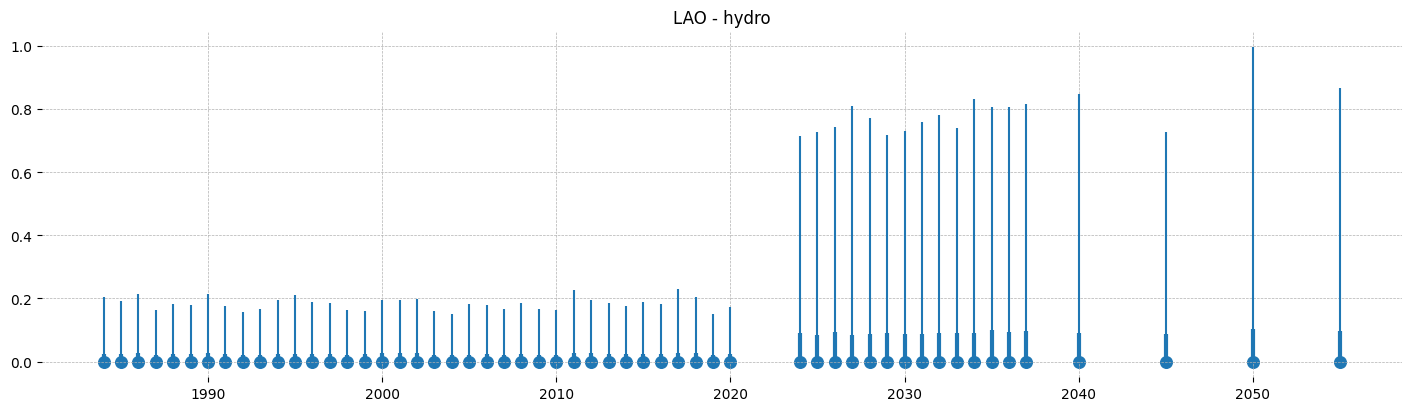

In [41]:
damage_plot( iso = 'LAO', idata= idata_post_combined, var_name= 'y_hat_damages' )

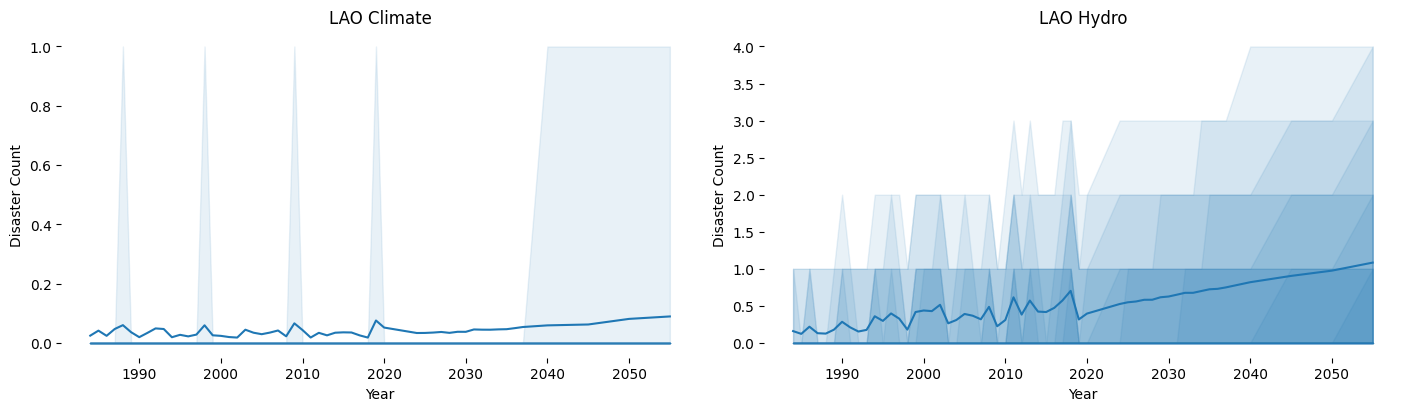

In [42]:
plot_predictions(idata_post_combined, 'LAO', 
                 'posterior_predictive',
                 obs_name= None, 
                 var_name= 'y_hat_n_events',
                 data= None)

# Integrating point predictions

In [236]:
# Set random seed
SEED = sum(list(map(ord, 'climate_bayes')))
rng = np.random.default_rng(SEED)

In [484]:
# Configure pytensir floats
floatX = pytensor.config.floatX
# Load idatas
points_idata = az.from_netcdf(here('notebooks/geo_damage_model/model_closest_full_long_no_squares.idata'))

points_idata = points_idata.rename({'country_effect': 'country_effect_points',
                                         'ISO': 'iso_points',
                                         'feature': 'feature_points',
                                         'beta' : 'beta_points'
                         })

#Drop chains to have same chain dim
chains_kep = [0,1,2,3,4,5]
merged_posteriors_0b = merged_posteriors_0.rename( {'iso': 'iso_curves'}).sel(chain= chains_kep)

#Merge posteriors
merged_posterior_1 = xr.merge([points_idata.posterior.drop_dims('obs_idx'),
                              merged_posteriors_0b])

### Points data

In [485]:
grid_cols =  [ 'long', 'lat', 'distance_to_river', 'log_distance_to_river', 'log_distance_to_coastline', 'geometry', 'ISO',
'log_distance_to_river__standardized', 'log_distance_to_coastline__standardized' , 'log_distance_to_river__standardized__squared',
'log_distance_to_coastline__standardized__squared']

#Load points data sets
sea_point_grid = pd.read_csv(here("data/sea_point_grid.csv"),index_col=0  )[grid_cols]
laos_point_grid = pd.read_csv(here("data/laos_point_grid.csv"),index_col=0 )[grid_cols]
sea_df = pd.read_csv(here("data/sea.csv"),index_col=0 )
lao_df = pd.read_csv(here("data/lao.csv"),index_col=0 )
sea_df_stand = pd.read_csv(here("data/sea_df_stand.csv"),index_col=0 )
lao_df_stand = pd.read_csv(here("data/lao_df_stand.csv"),index_col=0 )

# Load predictions
predictions_points = pd.read_csv(here("data/climate_forecast.csv")).rename(columns = {"time": "Start_Year"})

predictions_points["year"] =  pd.to_datetime(predictions_points['Start_Year'])

# Load IPCC data
ipcc_preds = pd.read_csv(here("data/ippc_projections.csv"), index_col=  "Year").head(14)

In [486]:
# create predictions_ISO
predictions_points["ISO"] = "LAO"

# Select years of interest
prediction_years = [x for x in curve_years[3:]]
predictions_short = predictions_points.query('year in @prediction_years')

# create grid point number
laos_point_grid = laos_point_grid.reset_index().rename(columns = {"index": "point_number" })

# merge grid and predictions
pred_df = pd.merge(laos_point_grid ,predictions_short, left_on= "ISO", right_on= "ISO", how = "left" )

# Create population density
pred_df["population_density"] = pred_df["Population"] / 236800 # Laos area in squared km hardcoded

# Calculate logs
pred_df["log_population_density"] = np.log(pred_df["population_density"])
pred_df["log_gdp_per_cap"] = np.log(pred_df["gdp_per_cap"])

In [487]:
# Define point features
point_features = ['lat', 'long', 'log_distance_to_river__standardized',
       'log_distance_to_coastline__standardized', 'Population__standardized',
       'co2__standardized', 'precip_deviation__standardized',
       'dev_ocean_temp__standardized', 'log_population_density__standardized',
       'log_gdp_per_cap__standardized',
       'log_gdp_per_cap__standardized__squared',
       'log_population_density__standardized__squared',
       # 'log_distance_to_river__standardized__squared',
       # 'log_distance_to_coastline__standardized__squared' 
                 ]

beta_point_features = point_features[2:]
distance_features = point_features[0:6]
time_varying_features = point_features[6:]
time_varying_features_base =[x[ :-14] for x in point_features[6:12]]

### Standardize data

In [488]:
################## standardize points data ##################
from sklearn.preprocessing import StandardScaler as Standardize

# Select cols to stand
cols_to_stand = ['Population', 'dev_ocean_temp',
                 'co2', 'log_population_density', 'log_gdp_per_cap',
       'precip_deviation',]

cols_to_stand_stand = [x + "__standardized" for x in  cols_to_stand]

cols_not_stand = ['ISO' , 'Start_Year', 'year', 'lat', 'long', 'geometry', 'point_number', 'log_distance_to_river__standardized',
       'log_distance_to_coastline__standardized', 'log_distance_to_river__standardized__squared','log_distance_to_coastline__standardized__squared']


#Train transformers
transformer_stand_  =  Standardize().fit(sea_df[cols_to_stand] )

# standardize pred_df
pred_df_stand = transformer_stand_.transform(pred_df[cols_to_stand] )
pred_df_stand = pd.DataFrame(pred_df_stand, columns =cols_to_stand_stand )
pred_df_stand = pd.merge(pred_df_stand, pred_df[cols_not_stand], left_index=True, right_index= True, how = "left" )

# Rename repeated variables
pred_df_stand =  pred_df_stand.rename(columns = {'co2__standardized': 'co2__standardized_p',
                                                'precip_deviation__standardized': 'precip_deviation__standardized_p'})

In [489]:
# Calculate logs squared
pred_df_stand["log_gdp_per_cap__standardized__squared"] = pred_df_stand["log_gdp_per_cap__standardized"] **2
pred_df_stand["log_population_density__standardized__squared"] = pred_df_stand["log_population_density__standardized"] **2

### Center Laos lat-long using SEA data

In [490]:
# Compute sea center
sea_center =  {}

# center Laos values
for x in ["lat", "long"]:
    sea_center[x] = (sea_df[x].max() + sea_df[x].min()) /  2
    pred_df_stand[x + "_centered"] = pred_df_stand[x] - sea_center[x]

In [491]:
# Merge with the damages and events join df
df_joint_to_merge =  df_joint_stand[features_events + damage_features_d_stand].loc['LAO']

In [492]:
### Create pred_df_stand_dict for several years
pred_df_stand_dict = {}

pred_df_stand.loc[ : , 'year'] =  pd.to_datetime(pred_df_stand['year'])
# pred_df_stand.loc[ : , 'year'] =pred_df_stand["Start_Year"].astype(int)

for year in pred_df_stand["year"].unique():
    pred_df_stand_dict[year.year] = pred_df_stand.query('year == @year')
    pred_df_stand_dict[year.year] = pd.merge( pred_df_stand_dict[year.year],
                                          df_joint_to_merge,
                                         on = 'year',
                                          how = 'left')
    pred_df_stand_dict[year.year].loc[:, 'iso']= 'LAO'

### Set coords

In [493]:
# Curve features

national_features = list(filter(lambda x: x != 'co2__standardized', damage_features_d_stand))
world_features = ['d_co2__standardized']

# class codes
pred_df_stand_dict[2030]['disaster_class'] = 'hydro'
class_idx_joint_2 =  pred_df_stand_dict[2030]['disaster_class'].map(class_to_idx.get)

# iso codes
codes_idx_joint_2=   pred_df_stand_dict[2030].reset_index()['iso'].map(codes_to_idx.get)


In [494]:
# gp features
gp_features = ["lat", "long"]

# Define point coords
is_disaster_idx_points , is_disaster_points  = pd.factorize(sea_df_stand['is_disaster'])
ISO_idx_points , ISO_points  = pd.factorize(sea_df_stand['ISO']) 
obs_idx_points  = sea_df_stand.index

gp_features = ['lat', 'long']

# Prediction coords
obs_idx = pred_df_stand_dict[2030]['point_number']

# Rebuild ISO_idx_sea
ISO_idx, ISO = pd.factorize(sea_df['ISO']) 

ISO_to_idx = {name: idx for idx, name in enumerate(ISO)}
ISO_idx_laos =  pred_df_stand_dict[2030].ISO.map(ISO_to_idx.get)

years = pred_df_stand['Start_Year'].unique()

ISO_curves_idx, ISO_curves =  pd.factorize(df_joint_stand.reset_index()['iso'] )
ISO_to_idx_2 = {name: idx for idx, name in enumerate(ISO_curves)}
ISO_curves_idx_laos =  pred_df_stand_dict[2030].iso.map(ISO_to_idx_2.get)

#


#Set coords_predictions
coords_flood_walls = {
    # 'is_disaster' : is_disaster,
        'obs_idx': obs_idx,
        'iso_curves':['LAO'], 
        'iso_points': ISO,
        'distance_features': distance_features,
        'time_varying_features' : time_varying_features,
        'point_features': point_features,
        'beta_point_features': beta_point_features,
        'gp_feature':gp_features,
        'features_events': features_events,
        'damage_features': damage_features_d_stand,
        'year':years,
        'national_feature': national_features,
        'world_feature': world_features,
        'disaster': ['climate', 'hydro'],
        'fixed_effect': ['iso', 'year'],
        'year_os' : list(years) + ['2030', '2045','2055']
                     }

# Compute point predictions

In [495]:
# Compute center function
def compute_center(X):
    return (pt.max(X, axis=0) + pt.min(X, axis=0)).eval() / 2

In [496]:
flood_wall_curves= {}
years = list(pred_df_stand_dict.keys())
# Build the models
for year in years:
    flood_wall_curves[year] =  points_model(coords =coords_flood_walls, 
                                            beta_point_features = beta_point_features,
                                            df = pred_df_stand_dict[year] , 
                                            gp_data =  pred_df_stand_dict[year][["lat_centered", "long_centered"]]
                                       )


In [497]:
idata_plot_point = {}
for year in years:
    with freeze_dims_and_data(flood_wall_curves[year] ):
        idata_plot_point[year] = pm.sample_posterior_predictive( points_idata.posterior.drop_dims('obs_idx') , 
                                                                    extend_inferencedata=False, 
                                                                    var_names=["event_prob_y_hat"])
                    

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

In [498]:
# Drop 2 chains
curves_pred_idata =  idata_post_combined.posterior_predictive.sel(chain = [0,1,2,3,4,5],
                                                                  obs_iso = 'LAO',
                                                                 disaster = 'hydro').rename({'obs_idx':'year' })

# merge idatas
final_idatas = {}
for year_ in years:
    final_idatas[year_] = xr.merge([idata_plot_point[year_].posterior_predictive,
                              curves_pred_idata.sel(year = pd.to_datetime( f'{year_}')) ])

    final_idatas[year_] = final_idatas[year_].drop(['obs_iso', 'disaster', 'obs_year'])

C:\Users\camil\AppData\Local\Temp\ipykernel_81548\622324062.py:12: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  final_idatas[year_] = final_idatas[year_].drop(['obs_iso', 'disaster', 'obs_year'])


In [499]:
simplified_coords = {}

simplified_coords['obs_idx'] = coords_flood_walls['obs_idx']
simplified_coords['obs_disaster_class'] = ['hydro']
simplified_coords['disaster'] = ['hydro']
simplified_coords['obs_iso'] = ['LAO']

In [500]:
with pm.Model(coords=simplified_coords) as point_curves_model:
    damages_curves = pm.Flat('damages_curves', dims = ['obs_disaster_class'])
    event_prob_y_hat = pm.Flat('event_prob_y_hat', dims = ['obs_idx'])

    point_damage_curve = pm.Deterministic('point_damage_curve', damages_curves * event_prob_y_hat , dims = ['obs_idx'])
    

In [501]:
point_damage_curves = {}
for year in years:
    with freeze_dims_and_data(point_curves_model ):
        point_damage_curves[year] = pm.sample_posterior_predictive( final_idatas[year]  ,  extend_inferencedata = True, 
                                                                        var_names=["point_damage_curve",])

        final_idatas[year] = xr.merge([point_damage_curves[year].posterior_predictive,
                             final_idatas[year]])

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

# City examples

In [502]:
# We now identify the cities

city_points = {'Vientiane': {'lat': 17.9757, 'long': 102.6331},
                            'Luang Prabang': {'lat': 19.8860, 'long': 102.1350},
                            'Savannakhet': {'lat': 16.5575, 'long': 104.7528},
                            'Pakse': {'lat': 15.1202, 'long': 105.7987},
                            'Thakhek': {'lat': 17.4106, 'long': 104.8304},
                        }

# Obtain the city points in the predictions
dist_square = {}
best_loc_index = {} 
best_loc = {}
cities = city_points.keys()

for city in cities:
    dist_square[city] = ((pred_df_stand_dict[2030]["lat"] -city_points[city]["lat"])**2 + (pred_df_stand_dict[2030]["long"] -city_points[city]["long"])**2)
    best_loc_index[city] =  dist_square[city].sort_values().head(1).index.values[0]
    best_loc[city] = pred_df_stand_dict[2030].loc[best_loc_index[city]][["lat", "long", "point_number"]]

In [503]:
# We select the city projections idata
city_predictions = {}

for city in cities:
    city_predictions[city] = {}
    for year in years:
        city_predictions[city][year] =  final_idatas[year].sel(obs_idx = best_loc[city]["point_number"] )

In [504]:
# We now build the return-year curves
computed_ry_damage = {}
curves_df_cities = {}  
curves_df_cities['no_fw'] = {}
for city in cities:
    computed_ry_damage[city] = {}
    curves_df_cities['no_fw'][city] = pd.DataFrame( )
    
    for year in years:
        
        damages = city_predictions[city][year]['point_damage_curve'].values.ravel()
        data = np.sort(damages)
        n = len(data)
        cdf_vals = np.linspace(1/n, 1, n)
        
        # Interpolate inverse CDF (PPF)
        ppf_func = interpolate.interp1d(cdf_vals, data, bounds_error=False, fill_value=(data[0], data[-1]))
        
        def compute_ry_damage(ry):
            return ppf_func(1 - 1/ry)
        
        rys = np.linspace(1, 100, num=10000)
        rys = np.append(rys, np.repeat(100, 10)/ np.array([0.01, 0.1, 0.2, 0.5, 1, 2, 10, 25, 50, 75]) )
        percentile = np.repeat(100, 10010) / rys
        year_ = year
        computed_ry_damage[city][year_] = pd.DataFrame({'percentile_inv': percentile, f'{year_}': compute_ry_damage(rys)},
                                                     ).set_index('percentile_inv').T
    
        #concat
        curves_df_cities['no_fw'][city] = pd.concat([curves_df_cities['no_fw'][city],computed_ry_damage[city][year_].T], axis=1)
        
    curves_df_cities['no_fw'][city]= curves_df_cities['no_fw'][city].reset_index()
    curves_df_cities['no_fw'][city] =  curves_df_cities['no_fw'][city].assign( percentile = lambda x:  100 -x["percentile_inv"] ).set_index('percentile')
    curves_df_cities['no_fw'][city] = curves_df_cities['no_fw'][city].sort_index(ascending= True)

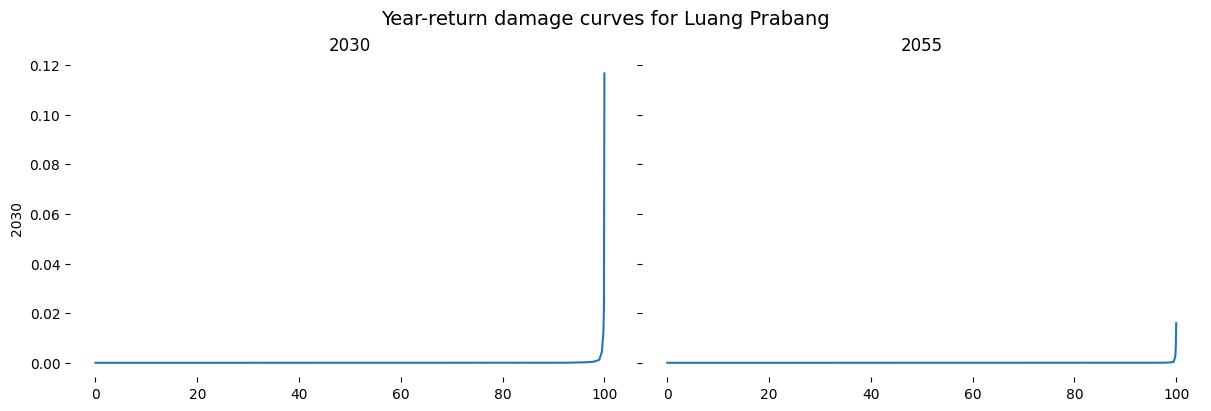

In [505]:
import seaborn as sns
fig, axes = plt.subplots(1, 2, figsize = (12, 4), sharey= True)
axes = axes.flatten()

city = 'Luang Prabang'

for year, n in zip([2030, 2055] , range(0,2)):
    sns.lineplot( data = curves_df_cities['no_fw'][city] , x = list(curves_df_cities['no_fw'][city].index), y = f'{year}', ax= axes[n])
    # axes[n].invert_xaxis()
    axes[n].set_title(f'{year}')

plt.suptitle(f'Year-return damage curves for {city}', size = 14);

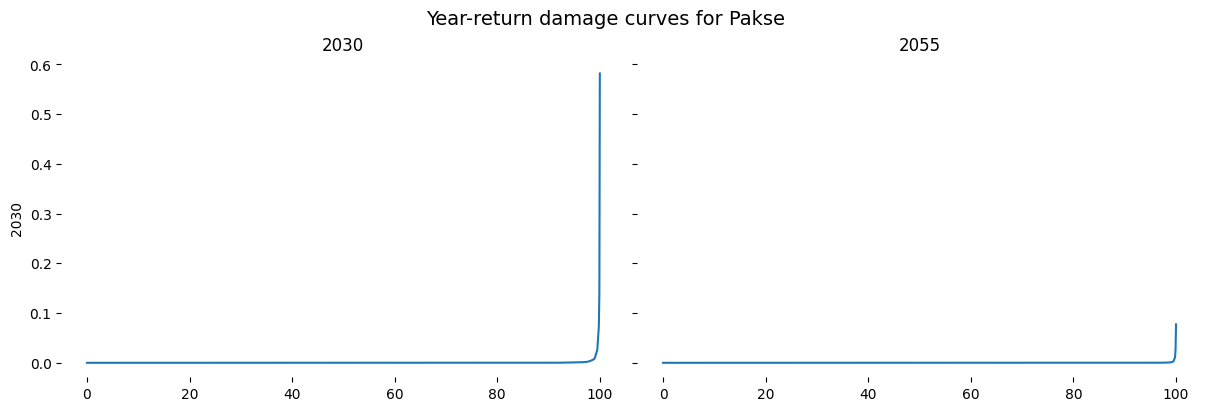

In [506]:
import seaborn as sns
fig, axes = plt.subplots(1, 2, figsize = (12, 4), sharey= True)
axes = axes.flatten()

city = 'Pakse'

for year, n in zip([2030, 2055] , range(0,2)):
    sns.lineplot( data = curves_df_cities['no_fw'][city] , x = list(curves_df_cities['no_fw'][city].index), y = f'{year}', ax= axes[n])
    # axes[n].invert_xaxis()
    axes[n].set_title(f'{year}')

plt.suptitle(f'Year-return damage curves for {city}', size = 14);

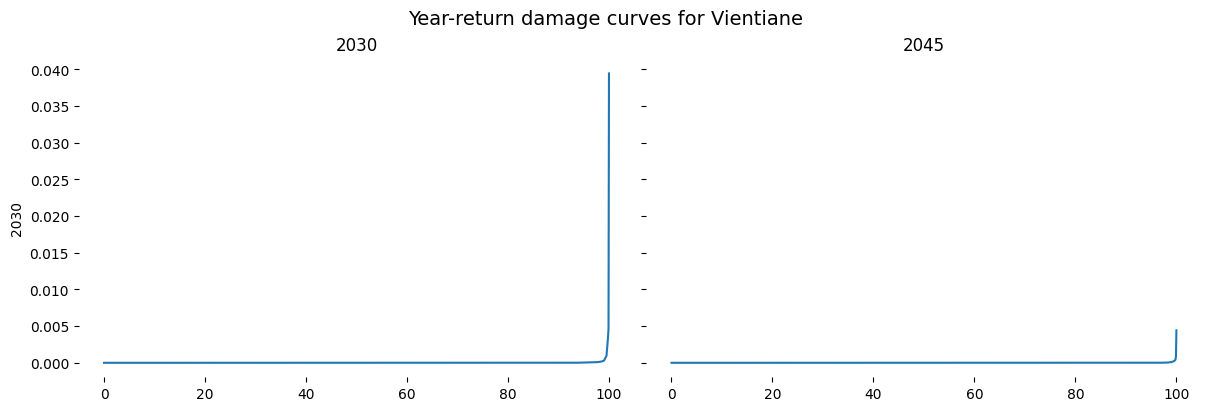

In [507]:
import seaborn as sns
fig, axes = plt.subplots(1, 2, figsize = (12, 4), sharey= True)
axes = axes.flatten()

city = 'Vientiane'

for year, n in zip([2030, 2045] , range(0,2)):
    sns.lineplot( data = curves_df_cities['no_fw'][city] , x = list(curves_df_cities['no_fw'][city].index), y = f'{year}', ax= axes[n])
    # axes[n].invert_xaxis()
    axes[n].set_title(f'{year}')

plt.suptitle(f'Year-return damage curves for {city}', size = 14);

# Predictions with IPCC data

In [508]:
ipcc_preds = pd.read_csv(here("data/ippc_projections.csv"), index_col=  "Year").head(14)

In [509]:
# Transform year index to date time
ipcc_preds.index = pd.to_datetime(ipcc_preds.index, format='%Y')
ipcc_preds["A1B"] = ipcc_preds["A1B"].astype(float)
full_years = pd.DataFrame(pd.to_datetime(predictions["year"]))
ipcc_preds_ext = pd.merge(full_years, ipcc_preds, right_index= True, left_on= "year", how = "left" )
ipcc_preds_ext.sort_index(inplace=True)

# Extract year
# ipcc_preds_ext["year"] = ipcc_preds_ext["year"].dt.year

ipcc_preds_ext.set_index("year", inplace= True)

# Perform linear interpolation
ipcc_preds_interpolated = ipcc_preds_ext.interpolate(method='linear').tail(110).head(86)

#Rename
ipcc_preds_interpolated = ipcc_preds_interpolated.reset_index()

# Create year_ to avoid merging problems
ipcc_preds_interpolated = ipcc_preds_interpolated.assign(year_ = lambda x: x.year.dt.year.astype(int) ).drop(columns = 'year')
predictions = predictions.assign(year_ = lambda x: x.year.dt.year.astype(int) )

In [510]:
# Merge with predictions 
pred_comparison_df = pd.merge(predictions, ipcc_preds_interpolated , on = 'year_', how = "left"  )

# we define the CO2 scenarios to use
scenarios_to_use = ['A2', 'B1',]
scenarios_to_use_stand = ["co2_" +  x + "__standardized" for x in scenarios_to_use]
scenarios_to_use_stand_d = ["d_co2_" + x + "__standardized" for x in scenarios_to_use]

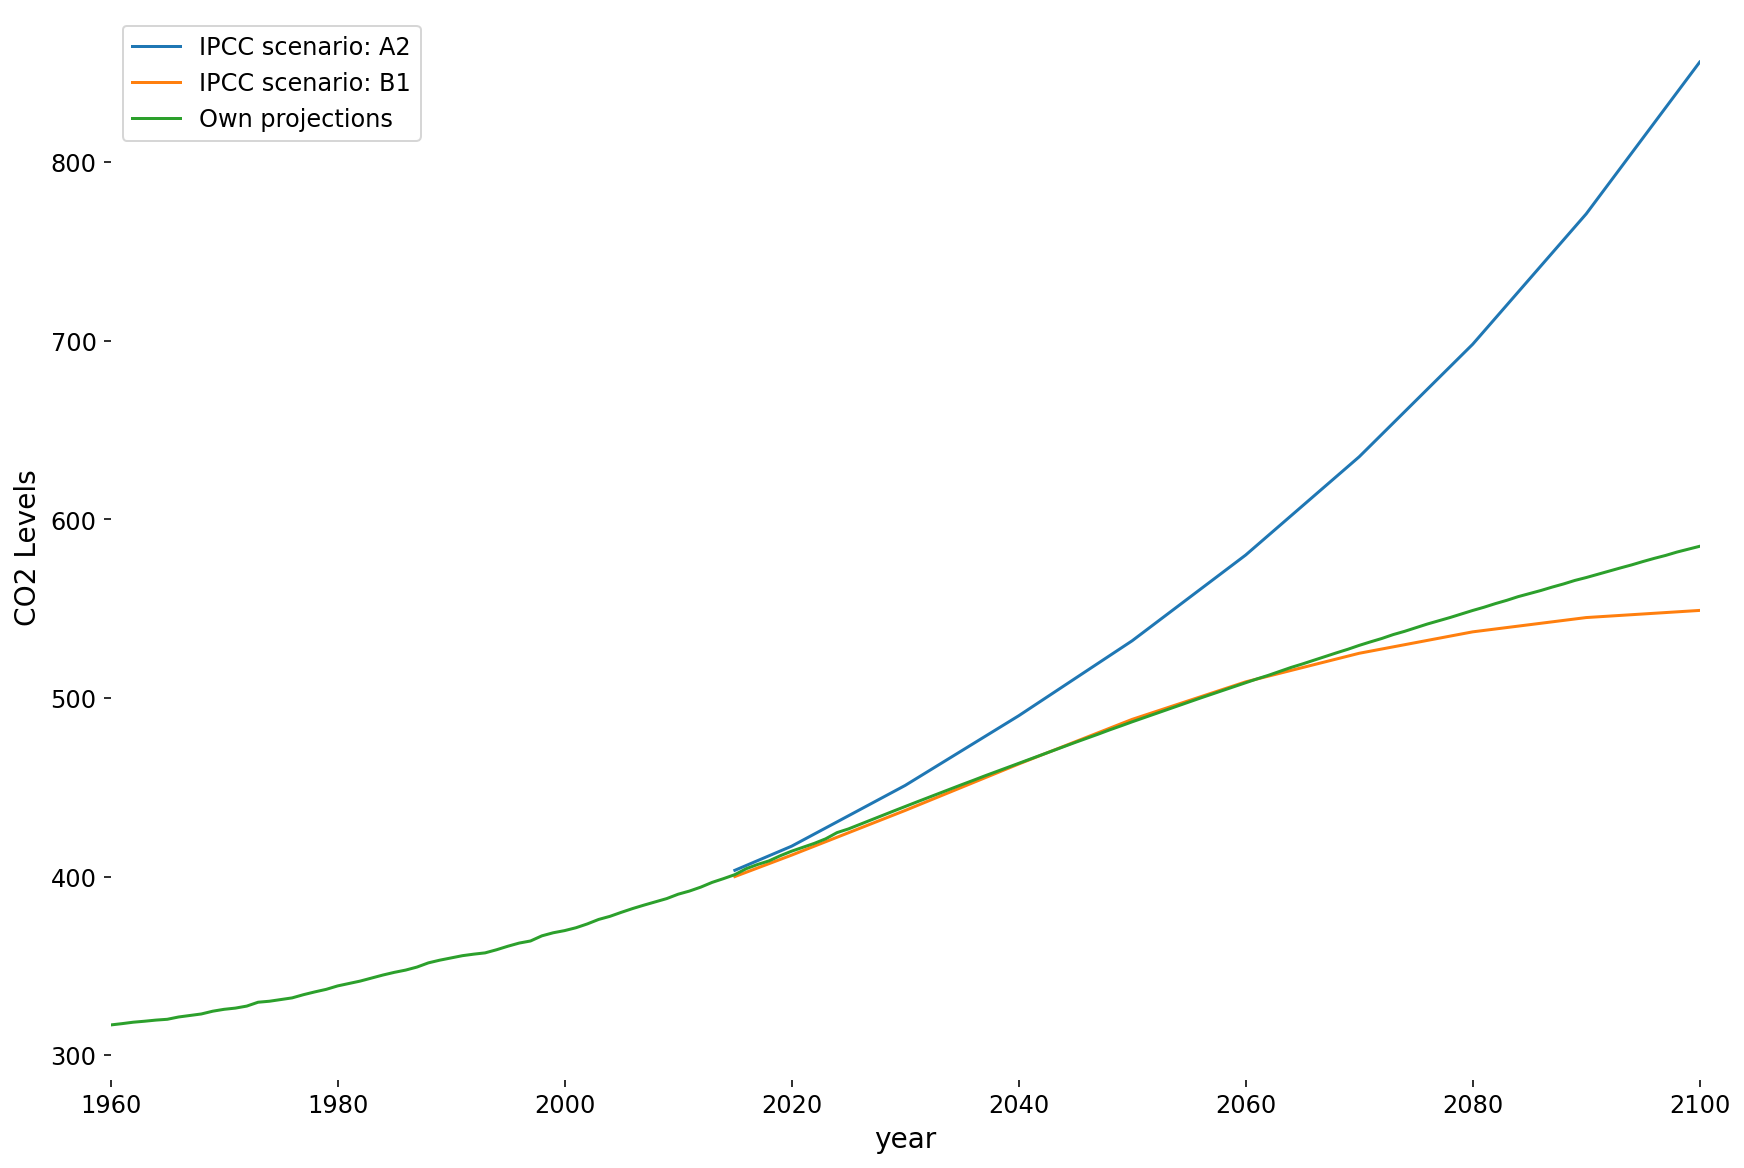

In [511]:
cols_to_plot = scenarios_to_use

fig, axes = plt.subplots(1, 1, figsize=(12, 8), sharex=True, dpi=144)

for series in cols_to_plot:
    sns.lineplot(x= pred_comparison_df["year_"], y= pred_comparison_df[series], ax=axes,
                 label="IPCC scenario: " + series)

sns.lineplot(x=pred_comparison_df["year_"], y= pred_comparison_df["co2"], ax=axes,
             label="Own projections")

axes.set_xlim(1960, 2100)

# Increase text size
# plt.title("IPCC Projections and Own Projections for CO2", fontsize=18)
axes.set_xlabel("year", fontsize=14)
axes.set_ylabel("CO2 Levels", fontsize=14)
axes.tick_params(axis='both', labelsize=12)
axes.legend(fontsize=12)


fig.savefig(here("notebooks/final_paper/figures/ipcc_co2_pred.png"));
plt.show()

In [512]:
# Now we standardize the CO2 scenarios for events and damages
for scenario in scenarios_to_use:
    df_damage[scenario] =  df_damage["co2"].copy()
    sea_df_stand[scenario] = sea_df_stand["co2"].copy()

# We train the transformers
transform_co2_d = Standardize().fit( df_damage[scenarios_to_use] )
transform_co2 = Standardize().fit(sea_df_stand[scenarios_to_use] )

# Drop the fake scenarios used to transform
df_damage= df_damage.drop(columns = scenarios_to_use)
sea_df_stand = sea_df_stand.drop(columns = scenarios_to_use)

# We transform the data
transformed_co2_d = transform_co2_d.transform(ipcc_preds_interpolated[scenarios_to_use] )
transformed_co2_d_df = pd.DataFrame(transformed_co2_d, columns = scenarios_to_use_stand_d)
ipcc_preds_interpolated = pd.merge(ipcc_preds_interpolated,transformed_co2_d_df, left_index=True, right_index=True, how = "left" )

transformed_co2 = transform_co2.transform(ipcc_preds_interpolated[scenarios_to_use] )
transformed_co2_df = pd.DataFrame(transformed_co2, columns = scenarios_to_use_stand)
ipcc_preds_interpolated = pd.merge(ipcc_preds_interpolated,transformed_co2_df, left_index=True, right_index=True, how = "left" )

In [516]:
# df_joint_stand = base_df_joint_stand.copy()

In [517]:
# Now we introduce the data into the predictions data frames
keys = list(pred_df_stand_dict.keys())

stand_ipcc_list = scenarios_to_use_stand + scenarios_to_use_stand_d

for date in keys:
    for projection in stand_ipcc_list:
        value = ipcc_preds_interpolated.query('year_ == @date')[projection].values[0]
        pred_df_stand_dict[date].loc[ : , projection] = value

# Create the year_ col
df_joint_stand =(  df_joint_stand.reset_index().assign(year_ = lambda x: x['year'].dt.year )
                 .set_index(['iso', 'year']).sort_index())



# merge with the projections
df_joint_stand = pd.merge(df_joint_stand.reset_index(),
                        ipcc_preds_interpolated[[ 'year_', 'A2', 'B1', 'd_co2_A2__standardized', 'd_co2_B1__standardized']],
                       on = 'year_',
                       how = "left").set_index(['iso', 'year']).sort_index()

for projection in [ 'd_co2_A2__standardized', 'd_co2_B1__standardized']:
   df_joint_stand[projection] = np.where(df_joint_stand['year_'] <= 2020, df_joint_stand['co2__standardized'], df_joint_stand[projection])

for projection in [ 'A2', 'B1']:
   df_joint_stand[projection] = np.where(df_joint_stand['year_'] <= 2020, df_joint_stand['co2'], df_joint_stand[projection])



In [518]:
# Now we adjust the features for the model
# Events
features_events_a2 = ['ln_population_density',
 'ln_gdp_pc',
 'square_ln_gdp_p',
 'precip_deviation',
 'A2',
 'population']

features_events_a2 = ['ln_population_density',
 'ln_gdp_pc',
 'square_ln_gdp_p',
 'precip_deviation',
 'B1',
 'population']

e_features_ipcc = [features_events_a2, features_events_a2 ]

# Damage 
damage_features_d_stand_a2 = ['ln_population_density__standardized',
 'ln_gdp_pc__standardized',
 'ln_gdp_pc__standardized_squared',
 'precip_deviation__standardized',
 'd_co2_A2__standardized',
 'population__standardized']

damage_features_d_stand_b1 = ['ln_population_density__standardized',
 'ln_gdp_pc__standardized',
 'ln_gdp_pc__standardized_squared',
 'precip_deviation__standardized',
 'd_co2_B1__standardized',
 'population__standardized']

d_features_ipcc = [damage_features_d_stand_a2, damage_features_d_stand_b1 ]

# Points
point_features_a2 = ['log_distance_to_river__standardized',
 'log_distance_to_coastline__standardized',
 'Population__standardized',
 'co2_A2__standardized',
 'precip_deviation__standardized',
 'dev_ocean_temp__standardized',
 'log_population_density__standardized',
 'log_gdp_per_cap__standardized',
 'log_gdp_per_cap__standardized__squared',
 'log_population_density__standardized__squared',
 # 'log_distance_to_river__standardized__squared',
 # 'log_distance_to_coastline__standardized__squared'
                    ]

point_features_b1 = ['log_distance_to_river__standardized',
 'log_distance_to_coastline__standardized',
 'Population__standardized',
 'co2_B1__standardized',
 'precip_deviation__standardized',
 'dev_ocean_temp__standardized',
 'log_population_density__standardized',
 'log_gdp_per_cap__standardized',
 'log_gdp_per_cap__standardized__squared',
 'log_population_density__standardized__squared',
 # 'log_distance_to_river__standardized__squared',
 # 'log_distance_to_coastline__standardized__squared'
                    ]

p_features = [point_features_a2, point_features_b1 ]

In [519]:
# Run the curves model
combined_model_ippc = {}
points_model_ippc = {}

combined_model_ippc_plot = {}
points_model_ippc_plot = {}

ipcc_point_projections = {}

for scenario, e_feature, d_feature, p_feature   in zip(scenarios_to_use, e_features_ipcc, d_features_ipcc, p_features):
    ipcc_point_projections[scenario] = {}
    
    combined_model_ippc[scenario]  = curves_model(coords = coords_combined , df = df_joint_stand ,
                                                        codes_idx_joint = codes_idx_joint,
                                                        features_events = e_feature,
                                                        damage_features_d_stand= d_feature,
                                                        class_idx_joint = class_idx_joint )

    with freeze_dims_and_data(combined_model_ippc[scenario] ):
        combined_model_ippc_plot[scenario] = pm.sample_posterior_predictive(merged_posteriors_0 , extend_inferencedata=False, 
                                                          compile_kwargs={'mode':'JAX'},
                                                    var_names=[ 
                                                        'damages_curves', 
                                                        'y_hat_damages',
                                                        'y_hat_n_events']
                                                           )

        combined_model_ippc_plot[scenario] = combined_model_ippc_plot[scenario].assign_coords(combined_xr_idx)
    

        # Drop the additioal chains and select the dimension
    combined_model_ippc_plot[scenario] =  combined_model_ippc_plot[scenario].posterior_predictive.sel(chain = [0,1,2,3,4,5],
                                                                  obs_iso = 'LAO',
                                                                 disaster = 'hydro').rename({'obs_idx':'year' })

    
    # Points model
    points_model_ippc[scenario] = {}
    points_model_ippc_plot[scenario] = {}
    for year in [2030, 2045, 2055]:     
        points_model_ippc[scenario][year] = points_model(coords = coords_flood_walls, 
                                            beta_point_features = p_feature,
                                            df = pred_df_stand_dict[year] , 
                                            gp_data =  pred_df_stand_dict[year][["lat_centered", "long_centered"]]
                                       )

        with freeze_dims_and_data( points_model_ippc[scenario][year] ):
            points_model_ippc_plot[scenario][year] = pm.sample_posterior_predictive( points_idata.posterior.drop_dims('obs_idx') , 
                                                                        extend_inferencedata=False, 
                                                                        var_names=["event_prob_y_hat"])

        # Merge idatas 
        ipcc_point_projections[scenario][year] = xr.merge( [points_model_ippc_plot[scenario][year].posterior_predictive,
                          combined_model_ippc_plot[scenario].sel(year = pd.to_datetime( f'{year}')) ])

        ipcc_point_projections[scenario][year] = ipcc_point_projections[scenario][year].drop(['obs_iso', 'disaster', 'obs_year'])

C:\Users\camil\miniforge3\envs\laos-climate-change\Lib\site-packages\pytensor\link\jax\linker.py:27: UserWarning: The RandomType SharedVariables [RNG(<Generator(PCG64) at 0x2043110BBC0>), RNG(<Generator(PCG64) at 0x204207C6B20>), RNG(<Generator(PCG64) at 0x20427D5E340>), RNG(<Generator(PCG64) at 0x20431109540>)] will not be used in the compiled JAX graph. Instead a copy will be used.
  warnings.warn(
C:\Users\camil\miniforge3\envs\laos-climate-change\Lib\functools.py:912: UserWarning: Skipping `CheckAndRaise` Op (assertion: sigma > 0) as JAX tracing would remove it.
  return dispatch(args[0].__class__)(*args, **kw)
Sampling: [y_hat_damages, y_hat_n_events]


Output()

Sampling: []


Output()

C:\Users\camil\AppData\Local\Temp\ipykernel_81548\2716751939.py:56: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  ipcc_point_projections[scenario][year] = ipcc_point_projections[scenario][year].drop(['obs_iso', 'disaster', 'obs_year'])
Sampling: []


...

C:\Users\camil\AppData\Local\Temp\ipykernel_81548\2716751939.py:56: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  ipcc_point_projections[scenario][year] = ipcc_point_projections[scenario][year].drop(['obs_iso', 'disaster', 'obs_year'])
Sampling: []


Output()

C:\Users\camil\AppData\Local\Temp\ipykernel_81548\2716751939.py:56: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  ipcc_point_projections[scenario][year] = ipcc_point_projections[scenario][year].drop(['obs_iso', 'disaster', 'obs_year'])
Sampling: []


Output()

C:\Users\camil\AppData\Local\Temp\ipykernel_81548\2716751939.py:56: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  ipcc_point_projections[scenario][year] = ipcc_point_projections[scenario][year].drop(['obs_iso', 'disaster', 'obs_year'])


In [520]:
computed_ry_damage_scen_scen = {}
curves_df_scen = {}  
retunr_year_tables = {}

for scenario in scenarios_to_use:
    computed_ry_damage_scen_scen[scenario] = {}
    curves_df_scen[scenario] = pd.DataFrame( )
    
    for year in [2030, 2045, 2055]:
        
        damages = ipcc_point_projections[scenario][year]['damages_curves'].values.ravel()
        data = np.sort(damages)
        n = len(data)
        cdf_vals = np.linspace(1/n, 1, n)
        
        # Interpolate inverse CDF (PPF)
        ppf_func = interpolate.interp1d(cdf_vals, data, bounds_error=False, fill_value=(data[0], data[-1]))
        
        def compute_ry_damage(ry):
            return ppf_func(1 - 1/ry)
        
        rys = np.linspace(1, 100, num=10000)
        rys = np.append(rys, np.repeat(100, 10)/ np.array([0.01, 0.1, 0.2, 0.5, 1, 2, 10, 25, 50, 75]) )
        percentile = np.repeat(100, 10010) / rys
        year_ = year
        computed_ry_damage_scen_scen[scenario][year_] = pd.DataFrame({'percentile_inv': percentile, f'{year_}': compute_ry_damage(rys)},
                                                     ).set_index('percentile_inv').T
    
        #concat
        curves_df_scen[scenario] = pd.concat([curves_df_scen[scenario],computed_ry_damage_scen_scen[scenario][year_].T], axis=1)
        
    curves_df_scen[scenario]= curves_df_scen[scenario].reset_index()
    curves_df_scen[scenario] =  curves_df_scen[scenario].assign( percentile = lambda x:  100 -x["percentile_inv"] ).set_index('percentile')
    curves_df_scen[scenario] = curves_df_scen[scenario].sort_index(ascending= True)
    retunr_year_tables[scenario] = build_return_years_curve( curves_df=  curves_df_scen[scenario])


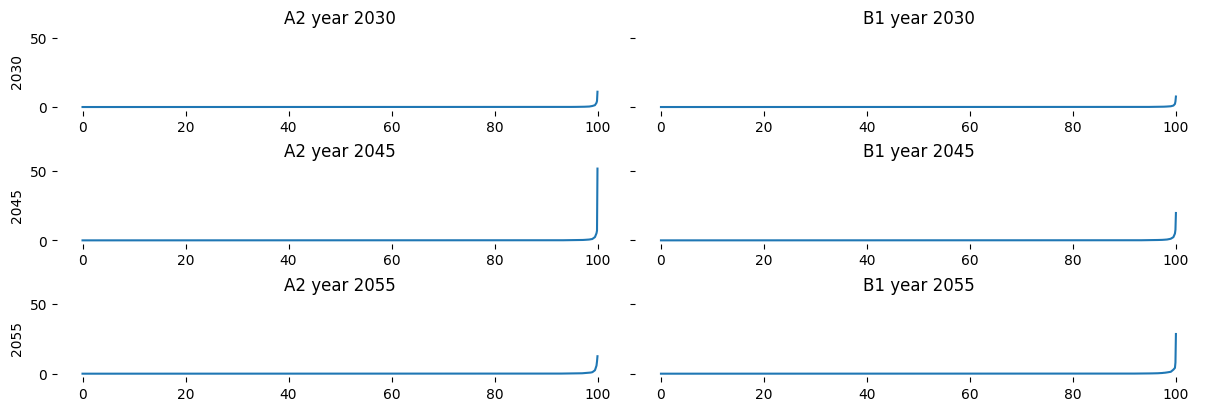

In [521]:
import seaborn as sns
fig, axes = plt.subplots(3, 2, figsize = (12, 4), sharey= True)

for scenario, n in zip(scenarios_to_use, range(0,2)):

    for year, m in zip([2030, 2045, 2055] , range(0,3)):
        sns.lineplot( data = curves_df_scen[scenario] ,
                     x = list(curves_df_scen[scenario].index), y = f'{year}', ax= axes[m,n])
        # axes[n].invert_xaxis()
        axes[m,n].set_title(f'{scenario} year {year}')
    
    # plt.suptitle(f'Year-return damage curves for {city}', size = 14);

In [522]:
table_A2_r = table_A2.rename(columns = {'2030': '2030_A2',
                           '2045': '2045_A2',
                           '2055': '2055_A2'})
table_B1_r = table_B1.rename(columns = {'2030': '2030_B1',
                           '2045': '2045_B1',
                           '2055': '2055_B1'})

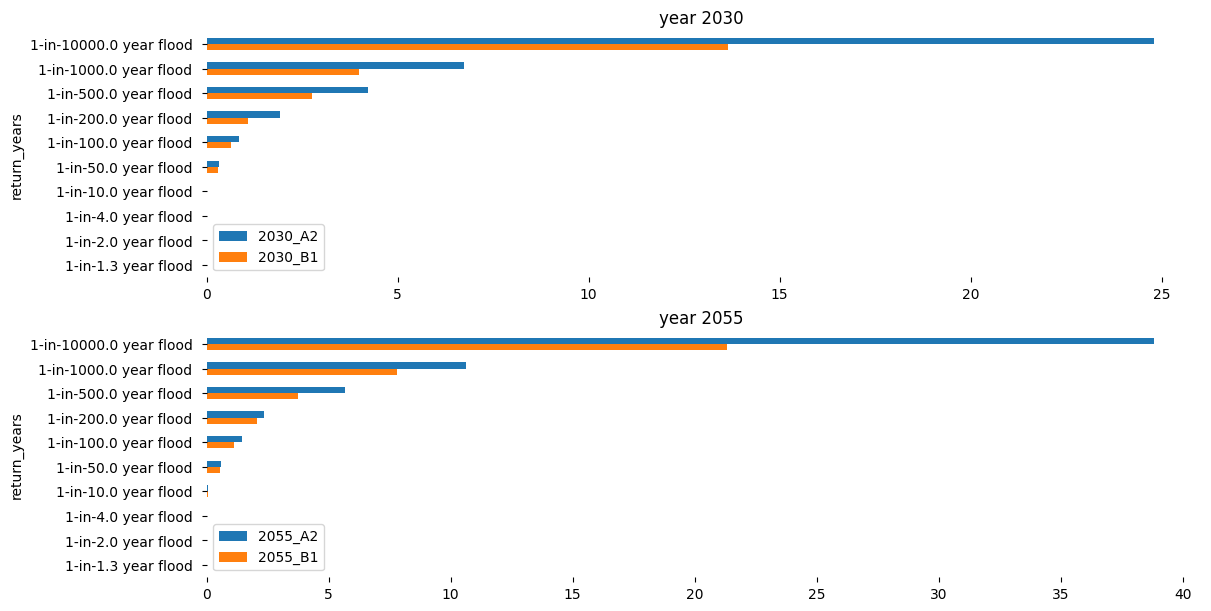

In [523]:
fig, axes = plt.subplots(2,1, figsize = (12,6) )
for a,b, n, year in zip( ['2030_A2', '2055_A2' ] ,  ['2030_B1', '2055_B1'], range(0,2), ['2030', '2055']):
    table_A2_r[[a]].join(table_B1_r[b] ).plot(kind = 'barh', ax = axes[n] )
    
    axes[n].invert_yaxis()
    axes[n].set_title(f'year {year} ')



# Modeling the construction of flood walls

For this exercise, we select two points:

Vientiane: The capital is located along the Mekong River and has experienced several major floods in the past. One of the most severe occurred in 2008.
Pakse: Situated on the Mekong River in southern Laos. Pakse has experienced seasonal flooding, particularly during heavy monsoons, with significant events recorded in 2013 and 2019.

In [524]:
# # We obtain the distance that minimizes the the damage effect
# beta_dist = (points_idata.posterior.sel(feature_points = 'log_distance_to_river__standardized').mean()['beta_points'].values)
# beta_dist_square = (points_idata.posterior.sel(feature_points = 'log_distance_to_river__standardized__squared').mean()['beta_points'].values)

# opt_dist = -beta_dist /(2*beta_dist_square)

In [562]:
wall_variables

['log_distance_to_river__standardized_wall',
 'log_distance_to_river__standardized__squared_wall']

In [601]:
# define loop variables
wall_cities = ["Vientiane", "Savannakhet", "Pakse"]
river_variables = ["log_distance_to_river__standardized", "log_distance_to_river__standardized__squared"]
wall_variables = [x + "_wall" for x in river_variables]
max_river_0 = pred_df_stand_dict[2030]["log_distance_to_river__standardized"].max()
# max_river_1 = max_river_0 **2

index_val = {}
city_pred_data = {}

wall_df = {}

# create the new distance to river variables (this is the core of the flood wall simulation)
for city in wall_cities:
    index_val[city] = {}
    city_pred_data[city] = {}
    for year in [2030, 2045, 2055]:
        wall_df[year] = pred_df_stand_dict[year].copy()
        # log_distance_to_river__standardized
        wall_df[year].loc[ : ,  wall_variables[0] ] = pred_df_stand_dict[year].loc[ : , "log_distance_to_river__standardized" ]
        wall_df[year].loc[ : ,  wall_variables[1] ] = pred_df_stand_dict[year].loc[ : , "log_distance_to_river__standardized__squared" ]
        
        point_num = best_loc[city].loc["point_number"]
        index_val[city][year] = pred_df_stand_dict[year].query('point_number == @point_num').index.values[0]
        
        # Re-write the values
        wall_df[year].loc[ : , wall_variables[0] ] = max_river_0

        # log_distance_to_river__standardized__squared
        wall_df[year].loc[ : , wall_variables[1] ] = max_river_1

        # Store the city values
        city_pred_data[city][year] =  wall_df[year].loc[index_val[city][year], : ]
        
    city_pred_data[city] = pd.DataFrame(city_pred_data[city]).T

In [602]:
# Define the wall features
event_features_wall = beta_point_features.copy()
event_features_wall[0] = "log_distance_to_river__standardized_wall"
# event_features_wall[-2] = "log_distance_to_river__standardized__squared_wall"

In [603]:
# Ruen the flood wall cases
flood_wall_model = {}
flood_wall_point_pred = {}
flood_wall_point_pred_merged = {}
final_flood_wall_idatas = {}
for year in years:
    # Create the model
    flood_wall_model[year] =  points_model(coords =coords_flood_walls, 
                                            beta_point_features = event_features_wall,
                                            df = wall_df[year] , 
                                            gp_data =  pred_df_stand_dict[year][["lat_centered", "long_centered"]]
                                       )
    # Sample the points flood_wall model
    with freeze_dims_and_data(flood_wall_model[year] ):
        flood_wall_point_pred[year] = pm.sample_posterior_predictive( points_idata.posterior.drop_dims('obs_idx') , 
                                                                    extend_inferencedata=False, 
                                                                    var_names=["event_prob_y_hat"])

    # Merge idatas 
    final_flood_wall_idatas[year] = xr.merge( [ flood_wall_point_pred[year].posterior_predictive,
                                                     curves_pred_idata.sel(year = pd.to_datetime( f'{year_}')) ])
    
    final_flood_wall_idatas[year] = final_flood_wall_idatas[year].drop(['obs_iso', 'disaster', 'obs_year'])

Sampling: []


Output()

C:\Users\camil\AppData\Local\Temp\ipykernel_81548\664495369.py:23: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  final_flood_wall_idatas[year] = final_flood_wall_idatas[year].drop(['obs_iso', 'disaster', 'obs_year'])
Sampling: []


Output()

C:\Users\camil\AppData\Local\Temp\ipykernel_81548\664495369.py:23: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  final_flood_wall_idatas[year] = final_flood_wall_idatas[year].drop(['obs_iso', 'disaster', 'obs_year'])
Sampling: []


Output()

C:\Users\camil\AppData\Local\Temp\ipykernel_81548\664495369.py:23: DeprecationWarning: dropping variables using `drop` is deprecated; use drop_vars.
  final_flood_wall_idatas[year] = final_flood_wall_idatas[year].drop(['obs_iso', 'disaster', 'obs_year'])


In [604]:
# Sample thepoint damage curve predictions
final_flood_wall_idatas_plot = {}
for year in years:
    with freeze_dims_and_data(point_curves_model ):
        final_flood_wall_idatas_plot[year] = pm.sample_posterior_predictive( final_flood_wall_idatas[year], extend_inferencedata = True, 
                                                                        var_names=["point_damage_curve",])

Sampling: []


Output()

Sampling: []


Output()

Sampling: []


Output()

In [605]:
# We select the city projections idata
city_predictions_flood_wall = {}

for city in cities:
    city_predictions_flood_wall[city] = {}
    for year in years:
        city_predictions_flood_wall[city][year] =  final_flood_wall_idatas_plot[year].posterior_predictive.sel(obs_idx = best_loc[city]["point_number"] )

In [606]:
city_predictions['Luang Prabang'][2030].mean()

<xarray.Dataset> Size: 44B
Dimensions:             ()
Coordinates:
    obs_idx             int32 4B 8050
Data variables:
    point_damage_curve  float64 8B 0.0001383
    event_prob_y_hat    float64 8B 0.0005476
    damages_curves      float64 8B 0.2378
    y_hat_damages       float64 8B 0.3208
    y_hat_n_events      float64 8B 0.8347

In [607]:
city_predictions_flood_wall['Luang Prabang'][2030].mean()

<xarray.Dataset> Size: 12B
Dimensions:             ()
Coordinates:
    obs_idx             int32 4B 8050
Data variables:
    point_damage_curve  float64 8B 6.643e-06

In [608]:
city_predictions_flood_wall['Luang Prabang'][2030].mean()

<xarray.Dataset> Size: 12B
Dimensions:             ()
Coordinates:
    obs_idx             int32 4B 8050
Data variables:
    point_damage_curve  float64 8B 6.643e-06

In [609]:
city_predictions_flood_wall['Luang Prabang'][2030].mean()

<xarray.Dataset> Size: 12B
Dimensions:             ()
Coordinates:
    obs_idx             int32 4B 8050
Data variables:
    point_damage_curve  float64 8B 6.643e-06

In [610]:
# Build the curve

# We now build the return-year curves
computed_ry_damage = {}
curves_df_cities['fw'] = {}
for city in cities:
    computed_ry_damage[city] = {}
    curves_df_cities['fw'][city] = pd.DataFrame( )
    
    for year in years:
        
        damages = city_predictions_flood_wall[city][year]['point_damage_curve'].values.ravel()
        data = np.sort(damages)
        n = len(data)
        cdf_vals = np.linspace(1/n, 1, n)
        
        # Interpolate inverse CDF (PPF)
        ppf_func = interpolate.interp1d(cdf_vals, data, bounds_error=False, fill_value=(data[0], data[-1]))
        
        def compute_ry_damage(ry):
            return ppf_func(1 - 1/ry)
        
        rys = np.linspace(1, 100, num=10000)
        rys = np.append(rys, np.repeat(100, 10)/ np.array([0.01, 0.1, 0.2, 0.5, 1, 2, 10, 25, 50, 75]) )
        percentile = np.repeat(100, 10010) / rys
        year_ = year
        computed_ry_damage[city][year_] = pd.DataFrame({'percentile_inv': percentile, f'{year_}': compute_ry_damage(rys)},
                                                     ).set_index('percentile_inv').T
    
        #concat
        curves_df_cities['fw'][city] = pd.concat([curves_df_cities['fw'][city],computed_ry_damage[city][year_].T], axis=1)
        
    curves_df_cities['fw'][city]= curves_df_cities['fw'][city].reset_index()
    curves_df_cities['fw'][city] =  curves_df_cities['fw'][city].assign( percentile = lambda x:  100 -x["percentile_inv"] ).set_index('percentile')
    curves_df_cities['fw'][city] = curves_df_cities['fw'][city].sort_index(ascending= True)

In [613]:
retunr_year_tables_cities = {}

for wall_c in ['fw', 'no_fw']:
    retunr_year_tables_cities[wall_c] = {}
    for city in cities:
        retunr_year_tables_cities[wall_c][city] = (build_return_years_curve( curves_df=  curves_df_cities[wall_c][city])
                                                   .rename(columns = {'2030': f'2030_{wall_c}',
                                                                       '2045': f'2045_{wall_c}',
                                                                       '2055': f'2055_{wall_c}'}))

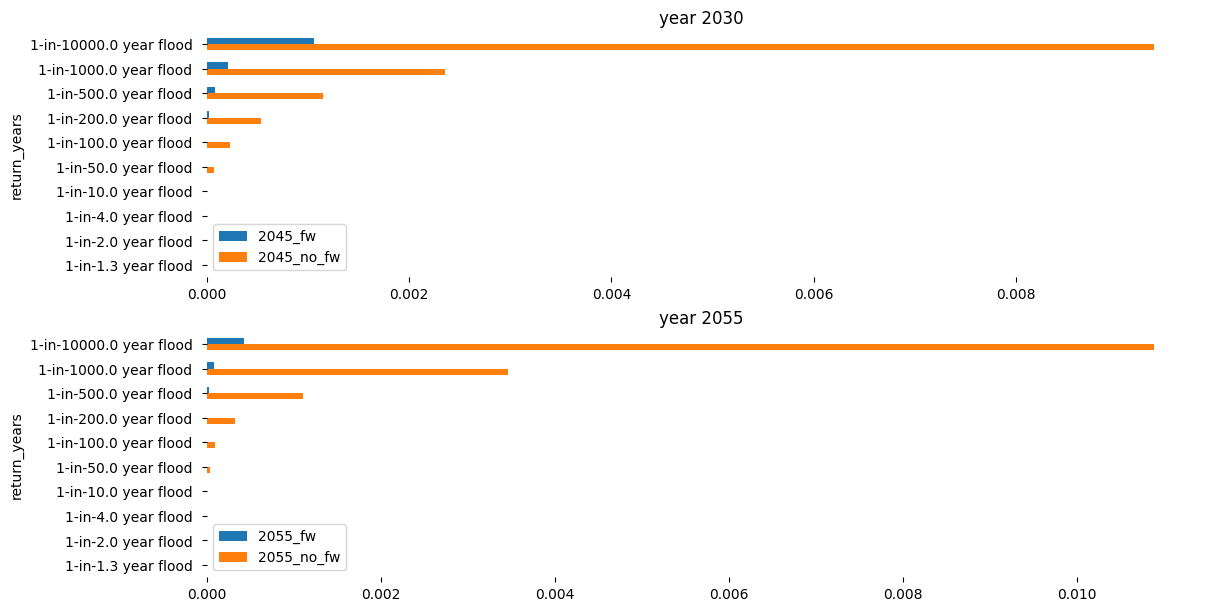

In [614]:
city = 'Savannakhet'

fig, axes = plt.subplots(2,1, figsize = (12,6) )
for a,b, n, year in zip( ['2045_fw', '2055_fw' ] ,  ['2045_no_fw', '2055_no_fw'], range(0,2), ['2030', '2055']):
    retunr_year_tables_cities['fw'][city][[a]].join( retunr_year_tables_cities['no_fw'][city][b]).plot(kind = 'barh', ax = axes[n] )
    
    axes[n].invert_yaxis()
    axes[n].set_title(f'year {year} ')

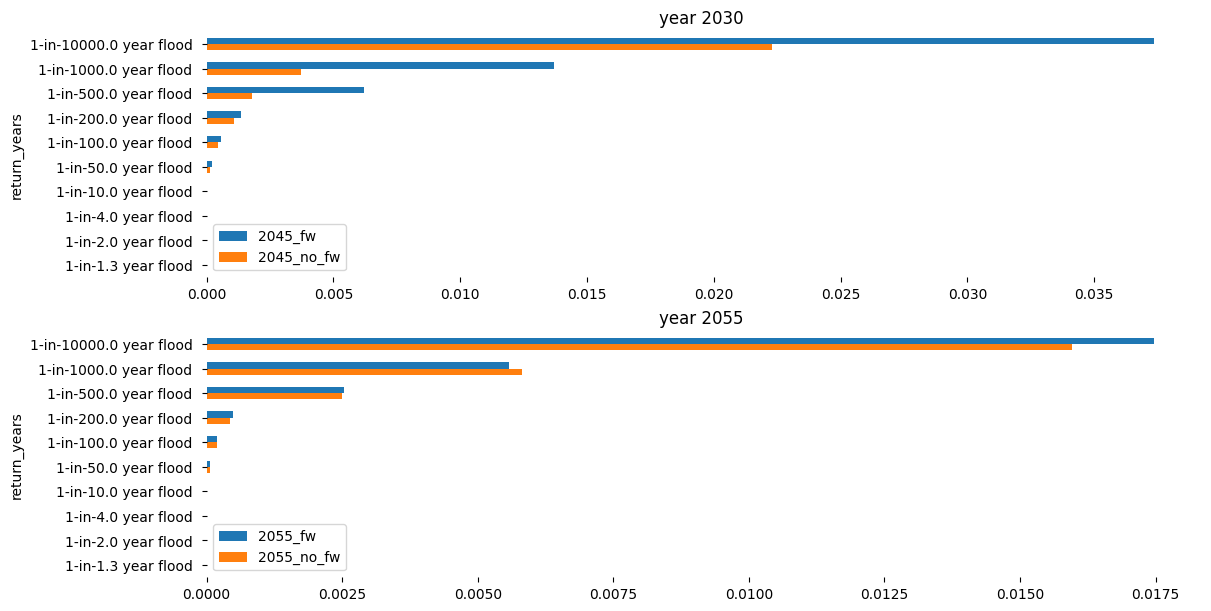

In [551]:
city = 'Luang Prabang'

fig, axes = plt.subplots(2,1, figsize = (12,6) )
for a,b, n, year in zip( ['2045_fw', '2055_fw' ] ,  ['2045_no_fw', '2055_no_fw'], range(0,2), ['2030', '2055']):
    retunr_year_tables_cities['fw'][city][[a]].join( retunr_year_tables_cities['no_fw'][city][b]).plot(kind = 'barh', ax = axes[n] )
    
    axes[n].invert_yaxis()
    axes[n].set_title(f'year {year} ')